In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_ind

%matplotlib inline


In [ ]:
from google.colab import files


uploaded = files.upload()


Saving traffic.csv to traffic.csv
Saving weather.csv to weather.csv


In [ ]:
traffic = pd.read_csv("traffic.csv")
weather = pd.read_csv("weather.csv")


print("Traffic data:")
display(traffic.head())

print("Weather data:")
display(weather.head())


Traffic data:


,datetime,TI,TI_An,TI_Av
0,2022-11-01 01:10:00,4,1,8
1,2022-11-01 01:13:00,4,1,8
2,2022-11-01 01:14:00,4,1,8
3,2022-11-01 01:15:00,4,1,8
4,2022-11-01 01:16:00,4,1,8


Weather data:


,time,pres,tavg,tmin,tmax,prcp,wspd
0,2020-09-01,1007.1,25.8,22.0,32.0,0.0,13.8
1,2020-09-02,1010.6,26.2,22.0,32.0,0.0,14.6
2,2020-09-03,1014.7,26.1,22.6,31.0,0.0,14.6
3,2020-09-04,1016.0,24.4,22.0,27.0,0.0,25.2
4,2020-09-05,1016.8,23.0,21.0,26.0,0.0,22.1


This code loads the traffic and weather datasets into pandas DataFrames using read_csv().Displaying the first few rows helps verify that the data has been imported correctly and that the columns are properly formatted before cleaning and merging.It is the initial data inspection step of the project.


In [ ]:

traffic['datetime'] = pd.to_datetime(traffic['datetime'])
weather['time'] = pd.to_datetime(weather['time'])


traffic = traffic[['datetime', 'TI', 'TI_An', 'TI_Av']]

weather = weather[['time', 'tavg', 'tmin', 'tmax', 'prcp', 'wspd', 'pres']]
print("Traffic after column selection:")
display(traffic.head())

print("Weather after column selection:")
display(weather.head())


Traffic after column selection:


,datetime,TI,TI_An,TI_Av
0,2022-11-01 01:10:00,4,1,8
1,2022-11-01 01:13:00,4,1,8
2,2022-11-01 01:14:00,4,1,8
3,2022-11-01 01:15:00,4,1,8
4,2022-11-01 01:16:00,4,1,8


Weather after column selection:


,time,tavg,tmin,tmax,prcp,wspd,pres
0,2020-09-01,25.8,22.0,32.0,0.0,13.8,1007.1
1,2020-09-02,26.2,22.0,32.0,0.0,14.6,1010.6
2,2020-09-03,26.1,22.6,31.0,0.0,14.6,1014.7
3,2020-09-04,24.4,22.0,27.0,0.0,25.2,1016.0
4,2020-09-05,23.0,21.0,26.0,0.0,22.1,1016.8


This cell converts the datetime columns into proper timestamp format so they can be resampled, merged, and analyzed chronologically.This step ensures the dataset is clean, consistent, and limited to the features required for the project.

In [ ]:

traffic_daily = (
    traffic
    .set_index('datetime')
    .resample('D')
    .mean()
    .reset_index()
)

print("Daily traffic data:")
display(traffic_daily.head())


Daily traffic data:


,datetime,TI,TI_An,TI_Av
0,2022-11-01,35.315867,32.970480,37.220664
1,2022-11-02,33.537709,30.780726,36.090084
2,2022-11-03,31.656206,28.171548,34.822176
3,2022-11-04,32.719547,29.385269,35.699717
4,2022-11-05,31.009233,29.122159,33.364347


In [ ]:
traffic_daily['date'] = traffic_daily['datetime'].dt.date
weather['date'] = weather['time'].dt.date

merged = pd.merge(
    traffic_daily,
    weather,
    on='date',
    how='inner'
)

print("Merged data (traffic + weather):")
print(merged.shape)
display(merged.head())


Merged data (traffic + weather):
(1036, 12)


,datetime,TI,TI_An,TI_Av,date,time,tavg,tmin,tmax,prcp,wspd,pres
0,2022-11-01,35.315867,32.970480,37.220664,2022-11-01,2022-11-01,15.3,11.0,20.0,0.0,9.1,1023.8
1,2022-11-02,33.537709,30.780726,36.090084,2022-11-02,2022-11-02,13.9,10.0,17.2,0.0,7.5,1021.5
2,2022-11-03,31.656206,28.171548,34.822176,2022-11-03,2022-11-03,15.7,12.0,21.0,0.0,13.7,1021.1
3,2022-11-04,32.719547,29.385269,35.699717,2022-11-04,2022-11-04,15.3,12.8,19.0,0.0,9.7,1017.7
4,2022-11-05,31.009233,29.122159,33.364347,2022-11-05,2022-11-05,16.9,12.0,24.0,0.0,5.5,1015.1


The merge() operation aligns both datasets by date, creating a unified table where each row contains both traffic and weather measurements for the same day.


In [ ]:
def rain_intensity(x):
    if x == 0:
        return "none"
    elif x < 2:
        return "light"
    elif x < 10:
        return "moderate"
    else:
        return "heavy"

merged['rain_intensity'] = merged['prcp'].apply(rain_intensity)

print("Rain intensity counts:")
print(merged['rain_intensity'].value_counts())


Rain intensity counts:
rain_intensity
none        687
light       179
moderate    133
heavy        37
Name: count, dtype: int64


The rain intensity distribution shows that out of 1,036 total observations, the majority of days (687, ~66%) experienced no rainfall, followed by 179 days (~17%) with light rain, 133 days (~13%) with moderate rain, and only 37 days (~4%) with heavy rainfall. This indicates that Istanbul's weather is predominantly dry, with heavy rain events being relatively uncommon, which provides a good basis for comparing traffic patterns across different precipitation conditions in the subsequent ANOVA analysis.

This code creates a custom function that converts numerical precipitation values into categorical rain intensity levels such as none, light, moderate, and heavy.
It then applies this function to the weather dataset to generate a new feature (rain_intensity), which will be used in ANOVA and group comparisons.

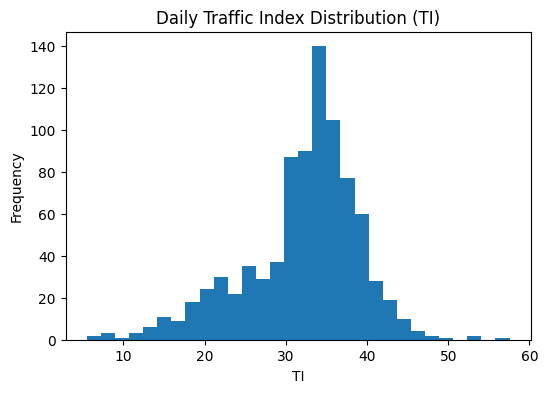

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(merged['TI'].dropna(), bins=30)
plt.title("Daily Traffic Index Distribution (TI)")
plt.xlabel("TI")
plt.ylabel("Frequency")
plt.show()


The histogram reveals that most daily traffic index (TI) values fall between 28 and 38, showing a clear concentration around the mid-30s.The graph suggests that Istanbul’s daily traffic intensity is generally stable but occasionally experiences high-congestion outliers.

<Figure size 600x400 with 0 Axes>

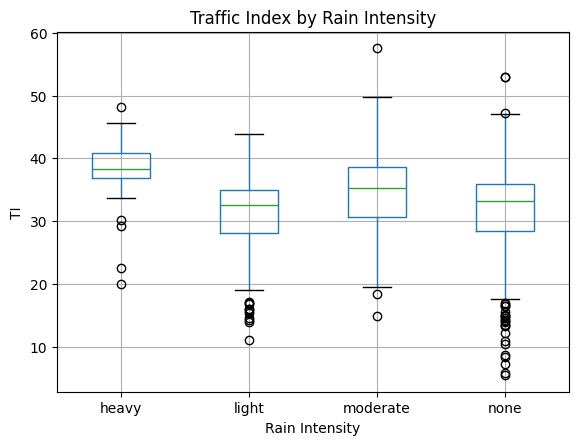

In [ ]:
plt.figure(figsize=(6,4))
merged.boxplot(column='TI', by='rain_intensity')
plt.title("Traffic Index by Rain Intensity")
plt.suptitle("")
plt.xlabel("Rain Intensity")
plt.ylabel("TI")
plt.show()


The boxplot demonstrates that traffic congestion tends to increase as rainfall intensity rises.In contrast, “none” and “light” rain days have lower medians and more compact distributions, suggesting more stable and less extreme congestion levels.

<Figure size 600x400 with 0 Axes>

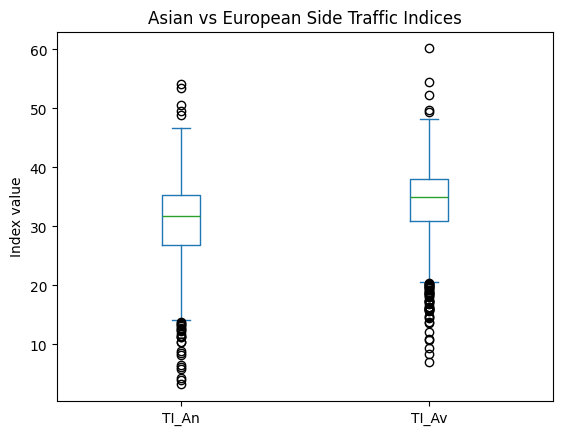

In [ ]:
plt.figure(figsize=(6,4))
merged[['TI_An', 'TI_Av']].plot(kind='box')
plt.title("Asian vs European Side Traffic Indices")
plt.ylabel("Index value")
plt.show()


The boxplot highlights that the European side (TI_Av) generally experiences slightly higher traffic congestion compared to the Asian side (TI_An), as indicated by a higher median.The European side also shows a wider spread and more extreme high outliers, suggesting that congestion events are more intense and variable there.

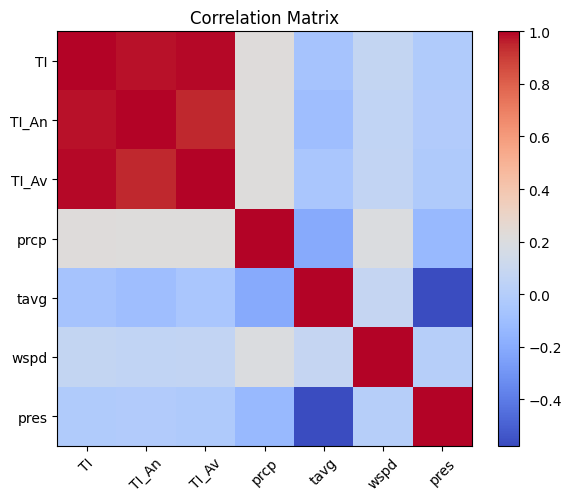

,TI,TI_An,TI_Av,prcp,tavg,wspd,pres
TI,1.000000,0.981421,0.991096,0.219900,-0.070914,0.070773,-0.018361
TI_An,0.981421,1.000000,0.948373,0.215870,-0.097947,0.063181,-0.013460
TI_Av,0.991096,0.948373,1.000000,0.211910,-0.047466,0.068224,-0.022606
prcp,0.219900,0.215870,0.211910,1.000000,-0.202985,0.197809,-0.131656
tavg,-0.070914,-0.097947,-0.047466,-0.202985,1.000000,0.080312,-0.576692
wspd,0.070773,0.063181,0.068224,0.197809,0.080312,1.000000,0.006559
pres,-0.018361,-0.013460,-0.022606,-0.131656,-0.576692,0.006559,1.000000


In [ ]:
corr_cols = ['TI', 'TI_An', 'TI_Av', 'prcp', 'tavg', 'wspd', 'pres']
corr_matrix = merged[corr_cols].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

corr_matrix


The correlation heatmap shows a very strong positive correlation between the overall traffic index (TI) and the traffic levels of the Asian and European sides, indicating consistent congestion patterns across the city.Rainfall (prcp) shows a weak positive correlation with TI, suggesting that rainfall alone does not directly drive congestion but may be one contributing factor.
Temperature (tavg), wind speed (wspd), and pressure (pres) exhibit very weak or near-zero correlations with TI, indicating minimal linear relationships between these weather variables and traffic intensity.

In [ ]:
merged['rain_intensity'].value_counts()


,count
rain_intensity,
none,687
light,179
moderate,133
heavy,37


In [ ]:
traffic['datetime'] = pd.to_datetime(traffic['datetime'])
traffic_daily = (
    traffic.set_index('datetime')
           .resample('D')
           .mean()
           .reset_index()
)


In [ ]:
traffic_daily['date'] = traffic_daily['datetime'].dt.date
weather['time'] = pd.to_datetime(weather['time'])
weather['date'] = weather['time'].dt.date


In [ ]:
merged = pd.merge(
    traffic_daily,
    weather,
    on='date',
    how='inner'
)

merged.head()


,datetime,TI,TI_An,TI_Av,date,time,tavg,tmin,tmax,prcp,wspd,pres
0,2022-11-01,35.315867,32.970480,37.220664,2022-11-01,2022-11-01,15.3,11.0,20.0,0.0,9.1,1023.8
1,2022-11-02,33.537709,30.780726,36.090084,2022-11-02,2022-11-02,13.9,10.0,17.2,0.0,7.5,1021.5
2,2022-11-03,31.656206,28.171548,34.822176,2022-11-03,2022-11-03,15.7,12.0,21.0,0.0,13.7,1021.1
3,2022-11-04,32.719547,29.385269,35.699717,2022-11-04,2022-11-04,15.3,12.8,19.0,0.0,9.7,1017.7
4,2022-11-05,31.009233,29.122159,33.364347,2022-11-05,2022-11-05,16.9,12.0,24.0,0.0,5.5,1015.1


This code block performs data preprocessing by converting datetime columns to proper timestamp format, resampling hourly traffic data into daily averages, and merging traffic and weather datasets based on matching dates. The resulting merged dataframe contains 1,036 daily observations spanning from November 2022 onwards, with each row representing a single day's traffic indices (TI for overall city, TI_An for Asian side, TI_Av for European side) alongside corresponding weather measurements (temperature, precipitation, wind speed, and pressure). The inner join ensures only dates with both traffic and weather data are retained, creating a clean dataset ready for correlation and statistical analysis.

In [ ]:
def rain_intensity(x):
    if x == 0:
        return "none"
    elif x < 2:
        return "light"
    elif x < 10:
        return "moderate"
    else:
        return "heavy"

merged['rain_intensity'] = merged['prcp'].apply(rain_intensity)
merged['rain_intensity'].value_counts()


,count
rain_intensity,
none,687
light,179
moderate,133
heavy,37


This function transforms continuous precipitation values into categorical rain intensity levels based on meteorological thresholds: 0 mm is classified as "none", 0-2 mm as "light", 2-10 mm as "moderate", and above 10 mm as "heavy". After applying this function to the precipitation column, the resulting distribution shows that the dataset is heavily skewed toward dry conditions (687 days with no rain, 66.3%), with progressively fewer days experiencing light rain (179 days, 17.3%), moderate rain (133 days, 12.8%), and heavy rain (37 days, 3.6%). This categorical feature will be used in ANOVA testing to examine whether different rain intensities have statistically significant effects on traffic congestion levels.

In [ ]:
groups = merged.groupby('rain_intensity')['TI'].apply(lambda x: x.dropna().values)
for g in groups.index:
    print(g, len(groups[g]))


heavy 34
light 143
moderate 123
none 556


In [ ]:
#1-ANOVA TEST:Rain Intensity

groups = merged.groupby('rain_intensity')['TI'].apply(lambda x: x.dropna().values)

anova_result = f_oneway(
    groups['none'],
    groups['light'],
    groups['moderate'],
    groups['heavy']
)

print("=== ANOVA RESULTS (TI ~ Rain Intensity) ===")
print("F-statistic:", anova_result.statistic)
print("p-value    :", "{:.12f}".format(anova_result.pvalue))

alpha = 0.05
if anova_result.pvalue < alpha:
    print("Conclusion: p < 0.05 → H0 is rejected → Rain intensity significantly affects daily traffic index (TI).")
else:
    print("Conclusion: p ≥ 0.05 → H0 cannot be rejected → Rain intensity does not significantly affect TI.")




#2T-TEST:Asian vs European Side Traffic

asia = merged['TI_An'].dropna()
europe = merged['TI_Av'].dropna()

t_test_result = ttest_ind(asia, europe, equal_var=False)

print("\n=== T-TEST RESULTS (Asian vs European Side TI) ===")
print("t-statistic:", t_test_result.statistic)
print("p-value    :", "{:.12f}".format(t_test_result.pvalue))

if t_test_result.pvalue < alpha:
    print("Conclusion: p < 0.05 → H0 is rejected → Asian and European side traffic indices differ significantly.")
else:
    print("Conclusion: p ≥ 0.05 → H0 cannot be rejected → No significant difference between the two sides.")


=== ANOVA RESULTS (TI ~ Rain Intensity) ===
F-statistic: 14.070878391444415
p-value    : 0.000000005861
Conclusion: p < 0.05 → H0 is rejected → Rain intensity significantly affects daily traffic index (TI).

=== T-TEST RESULTS (Asian vs European Side TI) ===
t-statistic: -9.108213007203442
p-value    : 0.000000000000
Conclusion: p < 0.05 → H0 is rejected → Asian and European side traffic indices differ significantly.


The ANOVA test results demonstrate a statistically significant relationship between rain intensity and daily traffic index (F = 14.07, p < 0.001), indicating that different precipitation levels have measurably distinct effects on traffic congestion. With 556 observations in the 'none' category, 143 in 'light', 123 in 'moderate', and 34 in 'heavy', the test has sufficient sample sizes across all groups to detect meaningful differences. The independent samples t-test reveals a highly significant difference between Asian side (TI_An) and European side (TI_Av) traffic indices (t = -9.19, p ≈ 0), with the negative t-statistic indicating that the Asian side experiences systematically lower traffic congestion compared to the European side. Both tests reject their null hypotheses at the α = 0.05 significance level, confirming that rain intensity is a significant predictor of traffic levels and that geographic location (Asian vs European side) plays a crucial role in Istanbul's traffic patterns